# The complete INTEGRATE workflow: from data to posterior


In [1]:
try:
    # Check if the code is running in an IPython kernel (which includes Jupyter notebooks)
    get_ipython()
    # If the above line doesn't raise an error, it means we are in a Jupyter environment
    # Execute the magic commands using IPython's run_line_magic function
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except:
    # If get_ipython() raises an error, we are not in a Jupyter environment
    # # # # #%load_ext autoreload
    # # # # #%autoreload 2
    pass

In [2]:
import os
import integrate as ig
from geoprior1d import geoprior1d

hardcopy = True
import matplotlib.pyplot as plt
import numpy as np
import copy

In [3]:
N = 2000000 # Number of prior model realizations to generate (this is just for testing, use a larger number for better results)

## GETTING THE DATA AND GEX FILE for gthe chosen area

In [4]:
case = 'DAUGAARD'
f_xlsx_files = ['daugaard_standard.xlsx','daugaard_valley.xlsx']
ig.get_case_data(case=case, filelist=['daugaard_standard.xlsx','daugaard_valley.xlsx'])
files = ig.get_case_data(case=case)
f_data_h5 = files[0]
file_gex= ig.get_gex_file_from_data(f_data_h5)

print("Using data file: %s" % f_data_h5)
print("Using GEX file: %s" % file_gex)

f_data_old_h5 = f_data_h5
f_data_h5 = f_data_h5.replace('.h5', '_WF.h5')
ig.copy_hdf5_file(f_data_old_h5, f_data_h5)



Getting data for case: DAUGAARD
--> Got data for case: DAUGAARD
Getting data for case: DAUGAARD
--> Got data for case: DAUGAARD
Using data file: DAUGAARD_AVG.h5
Using GEX file: TX07_20231016_2x4_RC20-33.gex


'DAUGAARD_AVG_WF.h5'

## the PRIOR model(s) :
simulate prior model realizations using geoprior1d # https://github.com/GEUSjesper/geoprior1d
We are using two prior models representing expected variability outstide and inside a buried valley system.

Using 32 parallel processes...


Generating priors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000000/2000000 [01:37<00:00, 20522.59real/s]


Prior generation completed in 99 seconds.
Using 32 parallel processes...


Generating priors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000000/2000000 [01:32<00:00, 21643.30real/s]


Prior generation completed in 96 seconds.


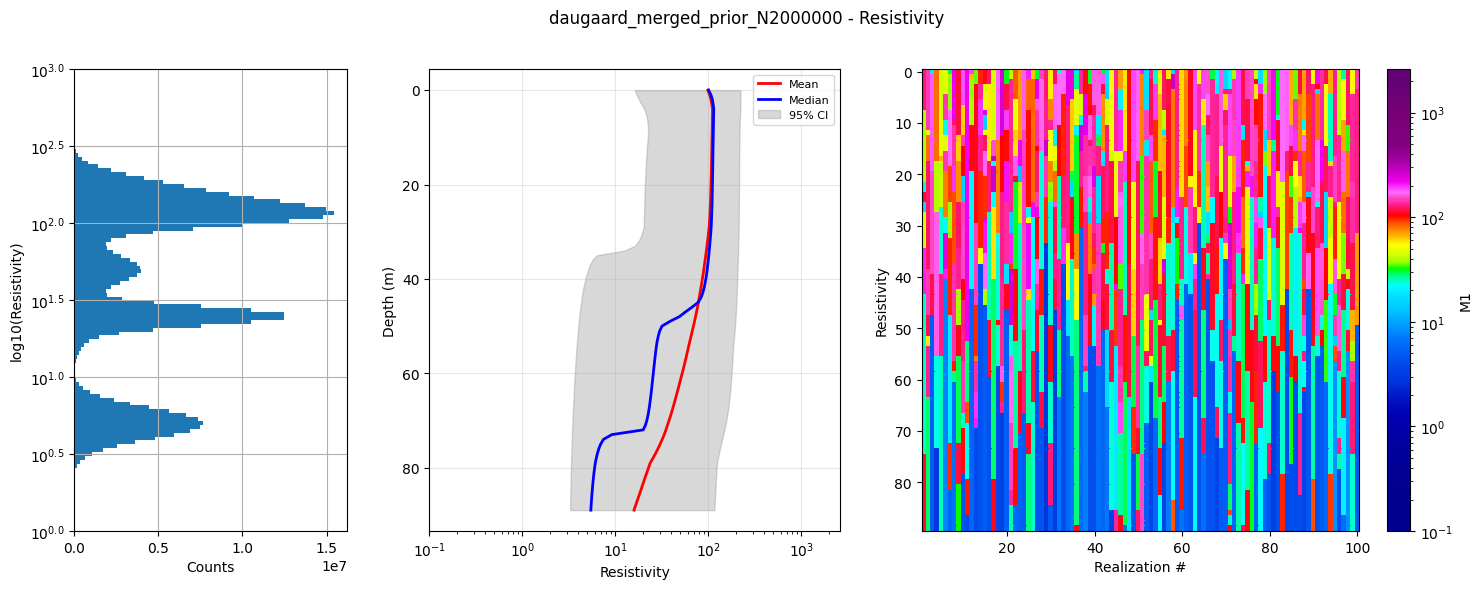

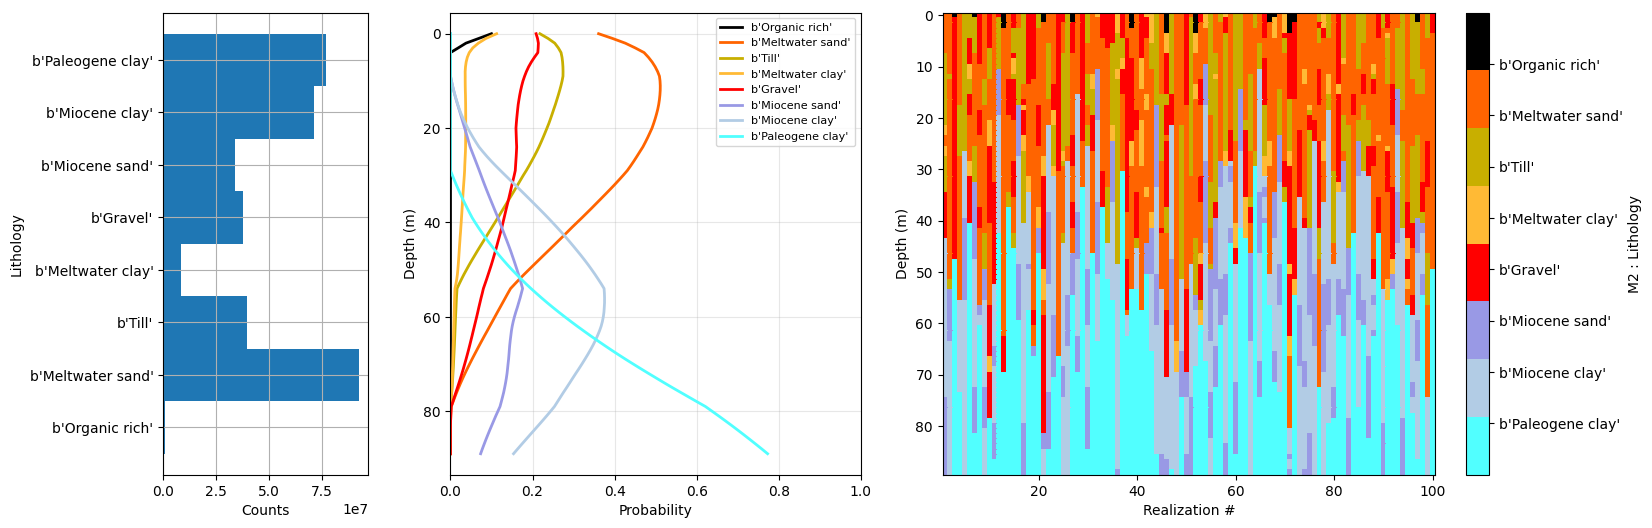

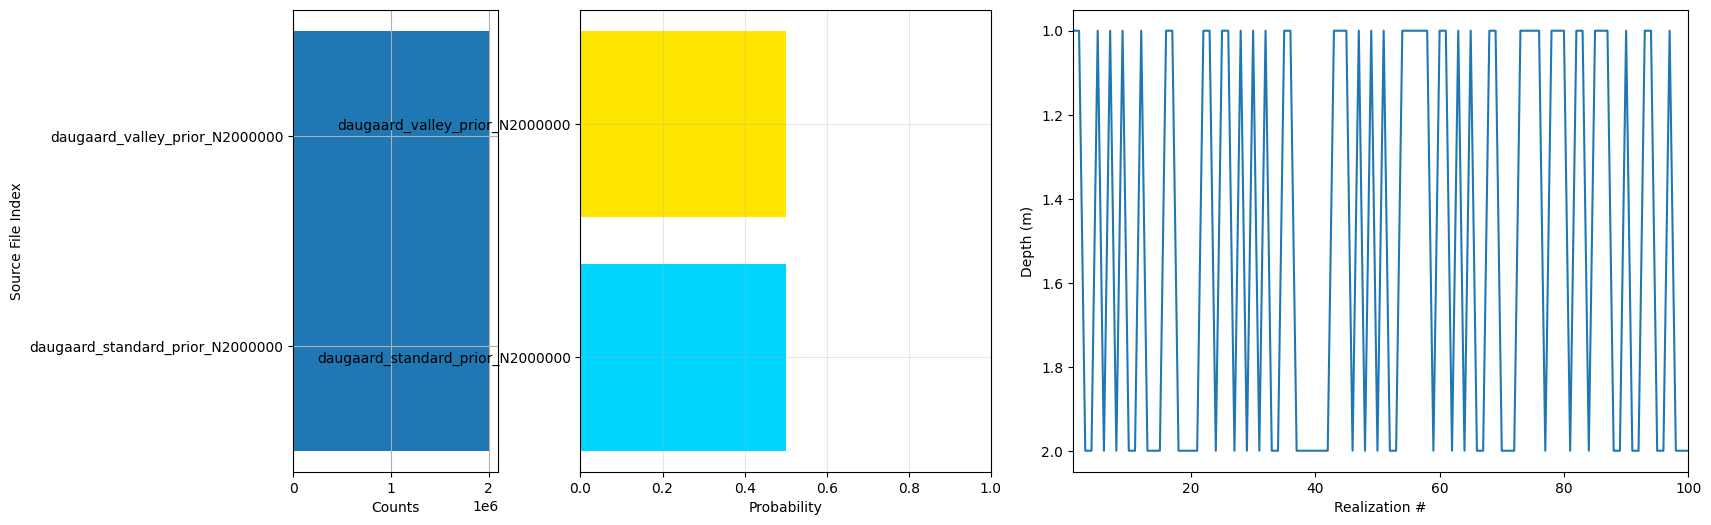

In [5]:
f_prior_h5_list = []
for file_xlsx in f_xlsx_files:
    # get filename without extension for naming the output hdf5 file
    fname = file_xlsx.split('.')[0]
    f_prior_h5, flags  = geoprior1d(file_xlsx, Nreals=N, dz=1, dmax =90, output_file='%s_prior_N%d.h5' % (fname, N))
    f_prior_h5_list.append(f_prior_h5)

# Merge the two prior hdf5 files into one, which will be used for the rest of the workflow. The merged file will be named 'daugaard_merged_prior_N10000.h5' (or with the appropriate N value).
f_prior_h5 = ig.merge_prior(f_prior_h5_list, f_prior_merged_h5='daugaard_merged_prior_N%d.h5' % N)
ig.plot_prior_stats(f_prior_h5, hardcopy=hardcopy)

## the tTEM DATA

In [6]:
useLogData = False # Whether to transform data to log10 space (recommended for resistivity data)
useCorrleatedNoise = False # Whether to use correlated noise (instead of uncorrelated) when generating the prior data. This can be more realistic for geophysical data, but it also increases the computational cost.
inflateNoise = 1 # Factor to increase noise level (std) in the data, to

In [7]:

if useLogData:
    f_data_h5_org = f_data_h5
    fname_data = f_data_h5.split('.')[0]
    f_data_h5 = '%s_LOGSPACE.h5' % fname_data
    ig.copy_hdf5_file(f_data_h5_org, f_data_h5)
    DATA = ig.load_data(f_data_h5_org)
    D_obs = DATA['d_obs'][0]
    D_std = DATA['d_std'][0]
    lD_obs = np.log10(D_obs)
    lD_std_up = np.abs(np.log10(D_obs+D_std)-lD_obs)
    lD_std_down = np.abs(np.log10(D_obs-D_std)-lD_obs)
    corr_std = 0.02
    lD_std = np.abs((lD_std_up+lD_std_down)/2) + corr_std
    if useCorrleatedNoise:
        # MISSING
        pass
    else:
        ig.save_data_gaussian(lD_obs, D_std = lD_std, f_data_h5 = f_data_h5, id=1, showInfo=0, is_log=1)



plot_data: Found data set D1
plot_data: Using data set D1


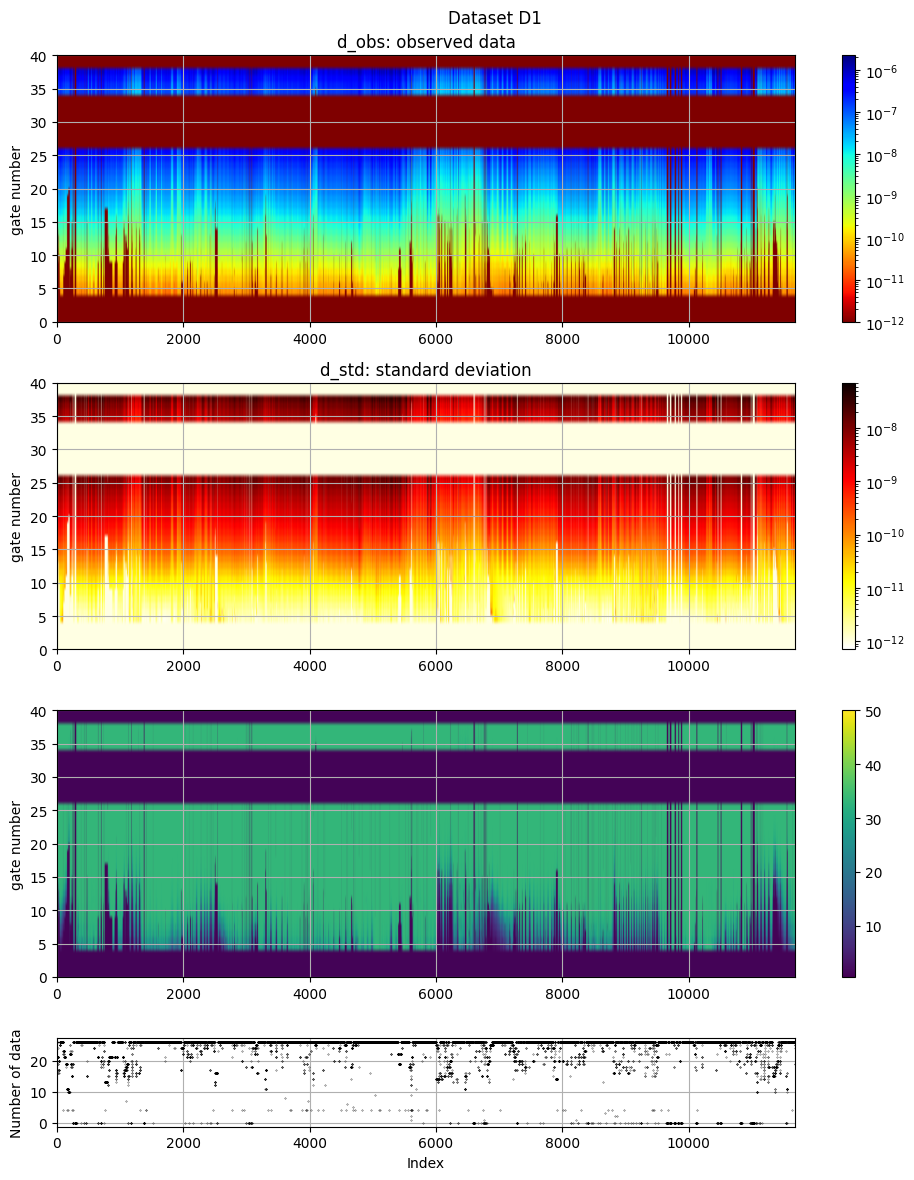

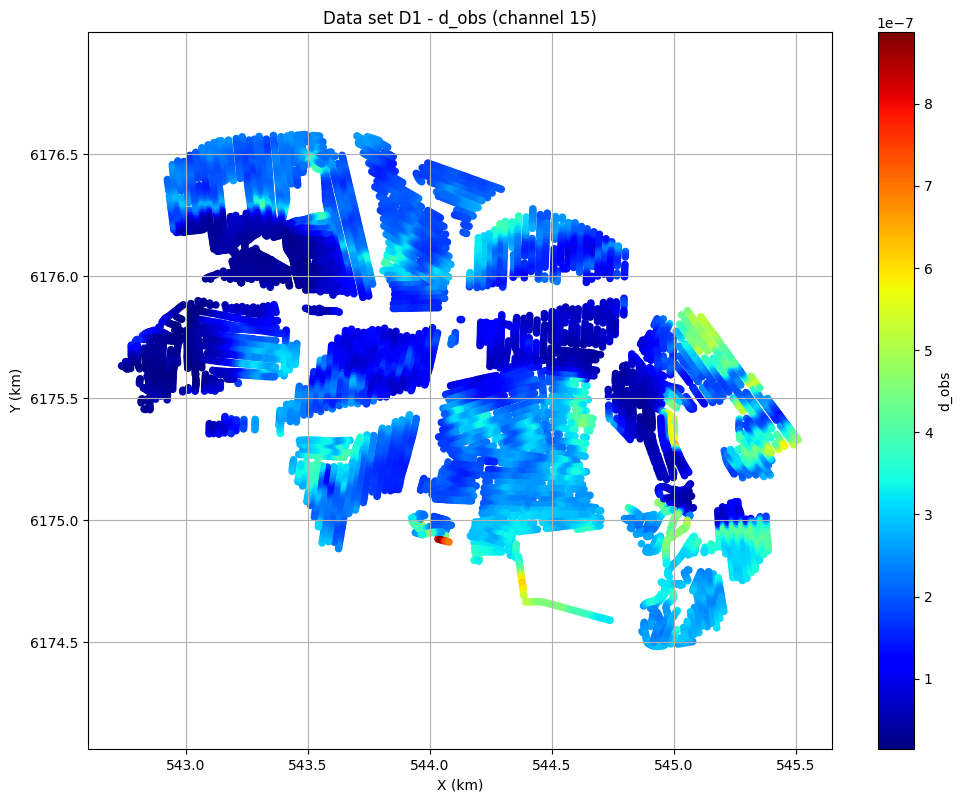

In [8]:
if inflateNoise != 1:
    gf=inflateNoise
    print("="*60)
    print("Increasing noise level (std) by a factor of %d" % gf)
    print("="*60)
    D = ig.load_data(f_data_h5)
    D_obs = D['d_obs'][0]
    D_std = D['d_std'][0]*gf
    f_data_old_h5 = f_data_h5
    f_data_h5 = '%s_gf%g.h5' % (fname_data, gf)
    ig.copy_hdf5_file(f_data_old_h5, f_data_h5)
    ig.save_data_gaussian(D_obs, D_std=D_std, f_data_h5=f_data_h5, file_gex=file_gex)

# The electromagnetic data (d_obs and d_std) can be plotted using ig.plot_data:
ig.plot_data(f_data_h5, hardcopy=hardcopy)
# Plot data channel 15 in an XY grid
ig.plot_data_xy(f_data_h5, data_channel=15, cmap='jet');

## the tTEM DATA

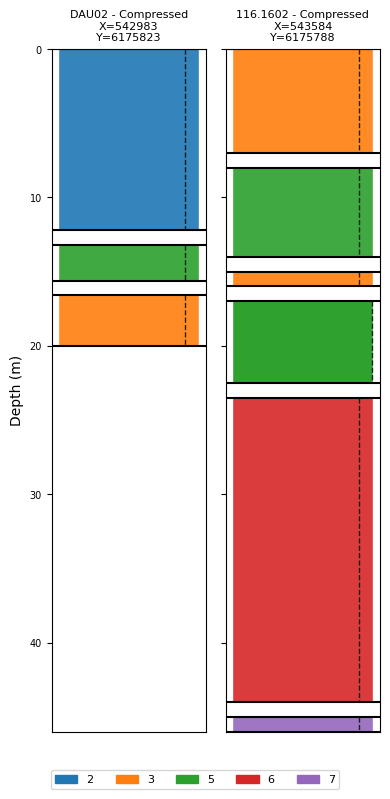

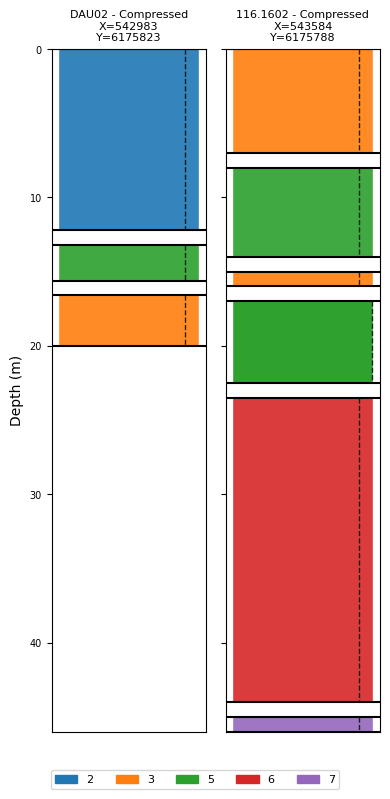

In [9]:
BHOLES=[]
P_single=0.9 # Probability assigned to the observed class in the prior model (for discrete parameters)

use_well_type = 'compressed' # Options: 'full', 'compressed', 'single_layer'
if use_well_type == 'full':
    BH = {}
    BH['depth_top'] =    [0  , 0.3, 0.5, 1, 1.5, 2, 10, 10.5, 13.2, 16.6]
    BH['depth_bottom'] = [0.3, 0.5, 1, 1.5, 2, 10, 10.5, 13.2, 16.6, 20]
    BH['class_obs'] = [2, 2, 2, 2, 2, 2, 5, 2, 5, 3]
    BH['class_prob'] = [P_single, P_single, P_single, P_single, P_single, P_single, P_single, P_single, P_single, P_single]
    BH['X'] = 542983.01
    BH['Y'] = 6175822.76
    BH['name'] = 'DAU02 - Full'
    BHOLES.append(BH)

    # WELL 2: 116.1602
    BH = {}
    BH['depth_top'] =     [0,  8, 15, 17, 20, 23.5, 45]
    BH['depth_bottom'] =  [8, 15, 17, 20, 23.5, 45, 46]
    BH['class_obs'] = [3,  5,  3,  5,  5,  6,  7]
    BH['class_prob'] = [P_single, P_single, P_single, P_single, P_single, P_single, P_single]
    BH['X'] = 543584.098
    BH['Y'] = 6175788.478
    BH['name'] = '116.1602 - Full'
    BHOLES.append(BH)

elif use_well_type == 'compressed':

    BH = {}
    BH['depth_top'] =    [0   , 13.2, 16.6]
    BH['depth_bottom'] = [12.2, 15.6, 20]
    BH['class_obs'] = [2, 5, 3]
    BH['class_prob'] = [P_single, P_single, P_single]
    BH['X'] = 542983.01
    BH['Y'] = 6175822.76
    BH['name'] = 'DAU02 - Compressed'
    BHOLES.append(BH.copy())

    BH = {}
    BH = BH.copy()
    BH['depth_top'] =     [0,  8, 15,   17, 23.5, 45]
    BH['depth_bottom'] =  [7, 14, 16, 22.5,   44, 46]
    BH['class_obs'] = [3,  5,  3,    5,    6, 7]
    BH['class_prob'] = [P_single, P_single, P_single, .99, P_single, P_single]
    BH['X'] = 543584.098
    BH['Y'] = 6175788.478
    BH['name'] = '116.1602 - Compressed'
    BHOLES.append(BH.copy())

else :
    # SINGLE LAYER: lithoilogy 5 from 20-24 m
    BH = {}
    BH['depth_top'] =     [20]
    BH['depth_bottom'] = [24]
    BH['class_obs'] = [5]
    BH['class_prob'] = [P_single]
    BH['X'] = 542983.01
    BH['Y'] = 6175822.76
    BH['name'] = 'DAU02'
    BHOLES.append(BH.copy())

    # SINGLE LAYER: lithoilogy 5 from 20-24 m
    BH = {}
    BH['depth_top'] =     [20]
    BH['depth_bottom'] = [24]
    BH['class_obs'] = [5]
    BH['class_prob'] = [P_single]
    BH['X'] = 543584.098
    BH['Y'] = 6175788.478
    BH['name'] = '116.1602 - Single Layer'
    BHOLES.append(BH.copy())

ig.plot_boreholes(BHOLES)

In [10]:
# Write each borehole to its own JSON file
for BH in BHOLES:
    fname = 'daugaard_borehole_%s.json' % BH['name'].replace(' ', '_').replace('/', '-')
    ig.write_borehole(BH, fname, showInfo=1)

# Write all boreholes together in one JSON file
ig.write_borehole(BHOLES, 'daugaard_boreholes.json', showInfo=1)

# Read back a single borehole and inspect it
BH_loaded = ig.read_borehole('daugaard_borehole_%s.json' % BHOLES[0]['name'].replace(' ', '_').replace('/', '-'), showInfo=1)
print('name    :', BH_loaded['name'])
print('X, Y    :', BH_loaded['X'], BH_loaded['Y'])
print('intervals:', list(zip(BH_loaded['depth_top'], BH_loaded['depth_bottom'])))
print('class_obs:', BH_loaded['class_obs'])

# Read back all boreholes at once
BHOLES_loaded = ig.read_borehole('daugaard_boreholes.json', showInfo=1)
for BH in BHOLES_loaded:
    print(f"  {BH['name']:30s}  {len(BH['depth_top'])} intervals  X={BH['X']:.1f}  Y={BH['Y']:.1f}")

write_borehole: wrote 1 borehole(s) to daugaard_borehole_DAU02_-_Compressed.json
write_borehole: wrote 1 borehole(s) to daugaard_borehole_116.1602_-_Compressed.json
write_borehole: wrote 2 borehole(s) to daugaard_boreholes.json
read_borehole: read 1 borehole(s) from daugaard_borehole_DAU02_-_Compressed.json
name    : DAU02 - Compressed
X, Y    : 542983.01 6175822.76
intervals: [(0, 12.2), (13.2, 15.6), (16.6, 20)]
class_obs: [2, 5, 3]
read_borehole: read 2 borehole(s) from daugaard_boreholes.json
  DAU02 - Compressed              3 intervals  X=542983.0  Y=6175822.8
  116.1602 - Compressed           6 intervals  X=543584.1  Y=6175788.5


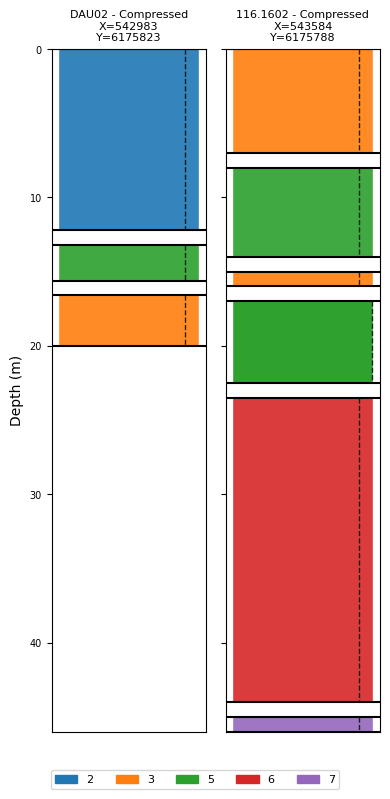

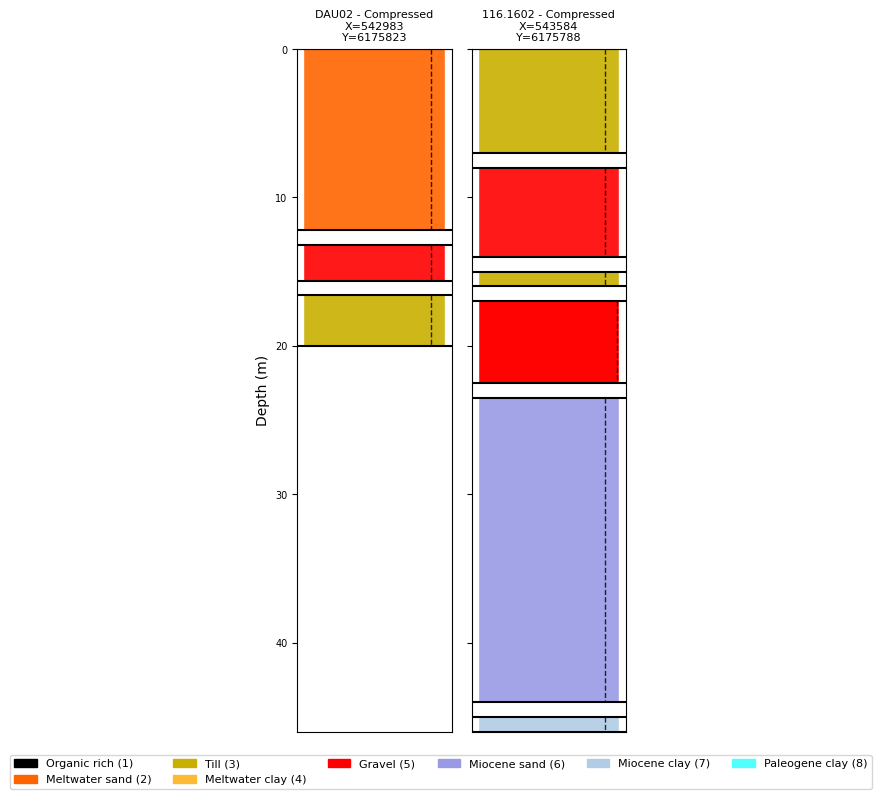

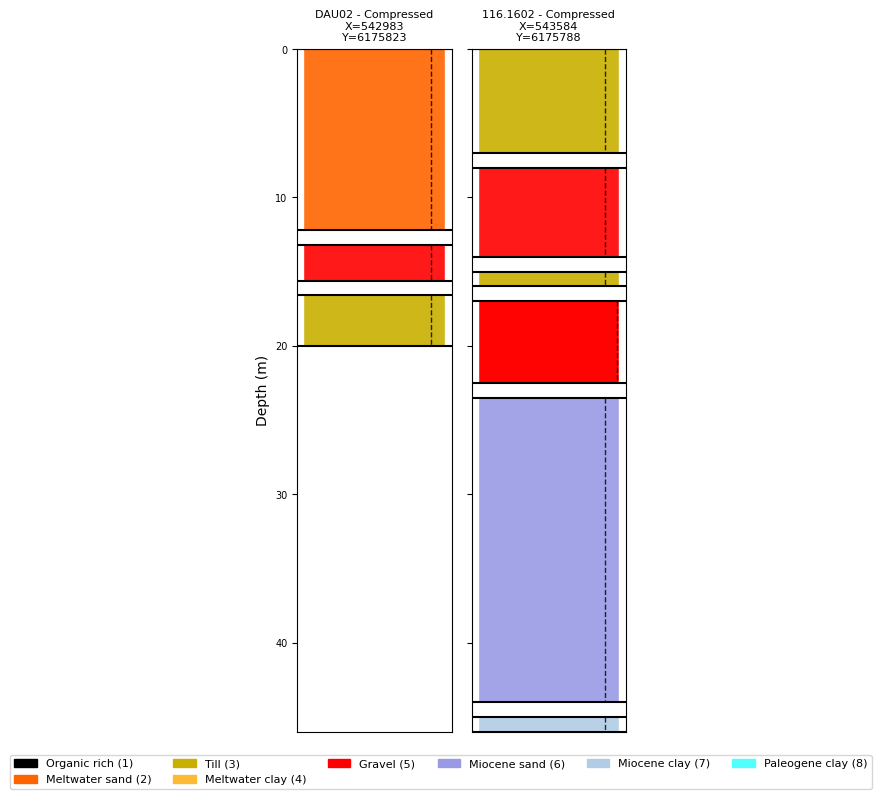

In [11]:
# Plot without prior info – classes labelled by numeric ID, default colours
ig.plot_boreholes(BHOLES)

# Plot without prior info 
ig.plot_boreholes(BHOLES, f_prior_h5)



## COMPUTE PRIOR DATA !!

In [12]:
f_prior_h5 = ig.prior_data_gaaem(f_prior_h5, file_gex, doMakePriorCopy=False)

prior_data_gaaem: Using 32 parallel threads.


prior_data_gaaem: Time=7981.8s/4000000 soundings.  2.0ms/sounding, 501.1it/s


prior_data_borehole: borehole=DAU02 - Compressed  method=mode_probability
compute_P_obs_sparse: Processing 4000000 realizations, 3 intervals
Using id=2
Trying to write D2 to DAUGAARD_AVG_WF.h5
Adding group DAUGAARD_AVG_WF.h5:D2 
save_borehole_data: DAU02 - Compressed  →  prior D2, data D2
prior_data_borehole: borehole=116.1602 - Compressed  method=mode_probability
compute_P_obs_sparse: Processing 4000000 realizations, 6 intervals
Using id=3
Trying to write D3 to DAUGAARD_AVG_WF.h5
Adding group DAUGAARD_AVG_WF.h5:D3 
save_borehole_data: 116.1602 - Compressed  →  prior D3, data D3


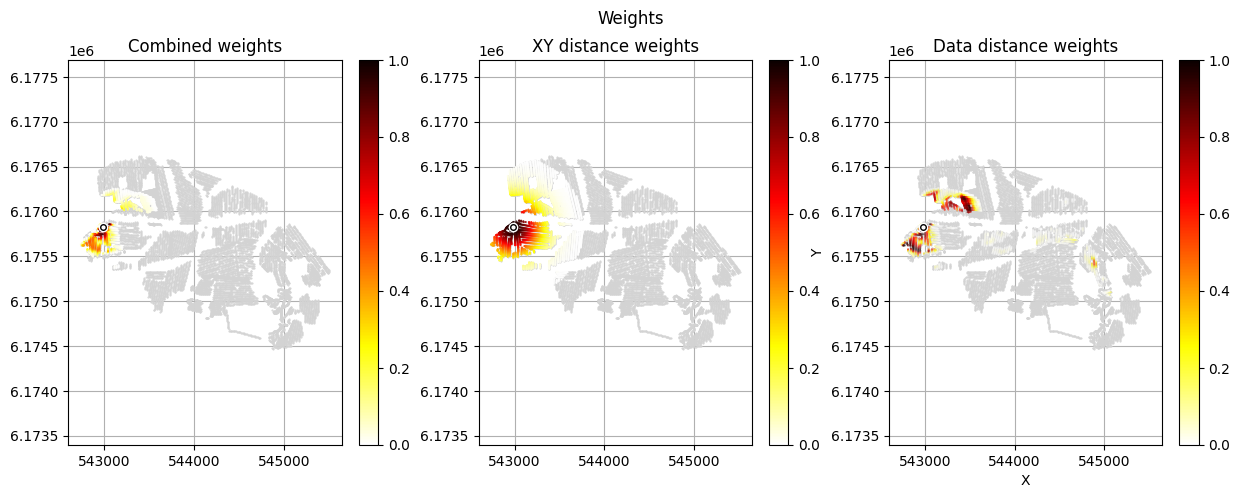

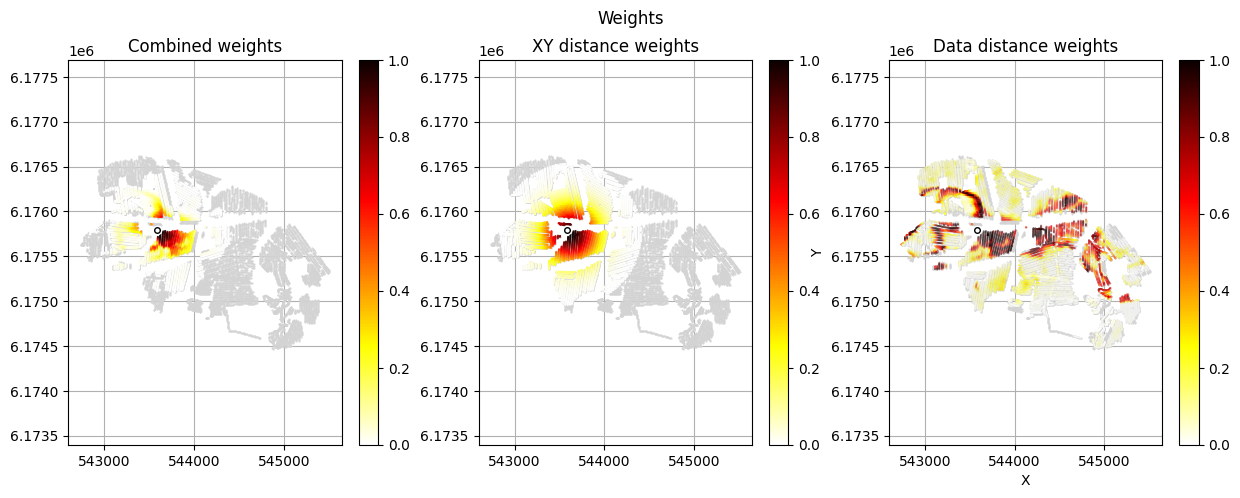

In [13]:
#
# For each borehole BH in BHOLES:
#   1. Compute prior borehole data (mode class per interval per realization)
#      and save to f_prior_h5  →  returns P_obs and id_prior
#   2. Extrapolate point observations across the survey grid with
#      distance-based weighting  →  d_obs, i_use
#   3. Save the observed borehole data to f_data_h5  →  id_out

im_prior = 2       # lithology model index (M2)
r_data   = 4       # tTEMN data based radius (db/dT) — If this is very high it will have no effect
r_dis    = 300     # fade-out radius (m) — weight approaches zero at this distance

# Compute and save prior + observed data for all boreholes in one step per borehole
id_borehole_list = []
for BH in BHOLES:
    id_prior, id_out = ig.save_borehole_data(
        f_prior_h5, f_data_h5, BH,
        im_prior=im_prior, r_data=r_data, r_dis=r_dis,
        doPlot=True,
        showInfo=1)
    id_borehole_list.append(id_out)

### Select a profile

Closest point to DAU02 - Compressed is at index 6344 with distance 0.0 m
Closest point to 116.1602 - Compressed is at index 7412 with distance 58.0 m


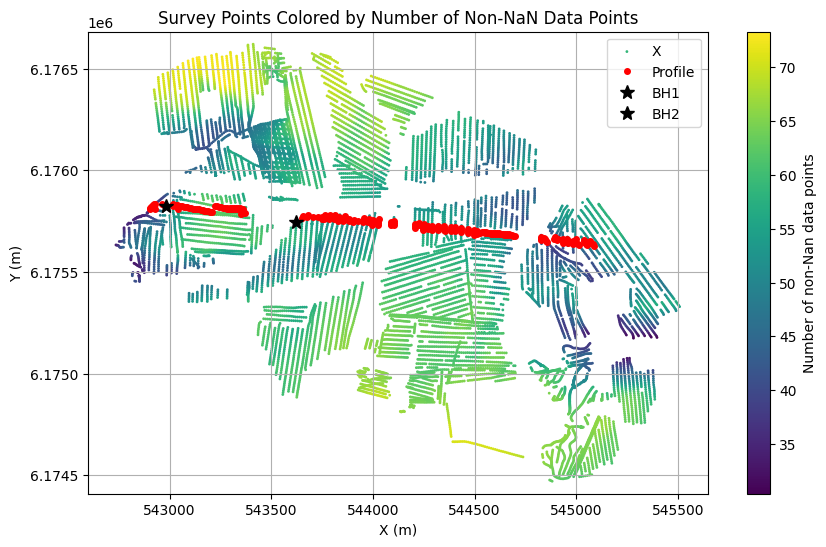

In [14]:
X, Y, LINE, ELEVATION = ig.get_geometry(f_data_h5)

# find the index of the [X,Y] points closts to the two boreholes
i_bh = []
for i, BH in enumerate(BHOLES):
    d = np.sqrt((X-BH['X'])**2 + (Y-BH['Y'])**2)
    i_closest = np.argmin(d)
    print("Closest point to %s is at index %d with distance %.1f m" % (BH['name'], i_closest, d[i_closest]))
    i_bh.append(i_closest)  
    

# Find points within buffer distance
Xl = np.array([BHOLES[0]['X']-100, BHOLES[0]['X'], BHOLES[1]['X'], BHOLES[1]['X']+1500])
Yl = np.array([BHOLES[0]['Y'], BHOLES[0]['Y'], BHOLES[1]['Y'], BHOLES[1]['Y']-150])
buffer = 15.0
indices, distances, segment_ids = ig.find_points_along_line_segments(
    X, Y, Xl, Yl, tolerance=buffer
)
id_line = indices

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, c=ELEVATION, s=1,label='X')
plt.plot(X[id_line],Y[id_line], 'r.', markersize=8, label='Profile', zorder=2, linewidth=5)
for i in range(len(i_bh)):
    plt.plot(X[i_bh[i]], Y[i_bh[i]], 'k*', markersize=10, label='BH%d' % (i+1), zorder=3)
plt.grid()
plt.colorbar(label='Number of non-Nan data points')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Survey Points Colored by Number of Non-NaN Data Points')
plt.axis('equal')
plt.legend()
if hardcopy:
    plt.savefig('DAUGAARD_survey_points_nonnan.png', dpi=300)
plt.show()

i1=np.min(id_line)
i2=np.max(id_line)+1

### INVERSION
The data is now ready for inversion with the rejection sampler.

On total we have 3 data types (one tTEM and two WellLog). They can be all jointly inverted (the default) or one can select which data types to ínver using `id_use`

    id_use = [1] # tTEM 
    id_use = [2] # Well 1
    id_use = [3] # Well 2
    id_use = [2,3] # Wells 1,2
    id_use = [1,2,3] # tTEM, Wells 1,2 (the default if id_use is not set)


In [15]:
# This prt of the can be rerun using different selection of data types without rerunning the abobe parts
nr=1000
id_use_arr = []
#id_use_arr.append([1]) # tTEM 
#id_use_arr.append([2]) # Well 1
#id_use_arr.append([3]) # Well 2
id_use_arr.append([2,3]) # Well 1,2
id_use_arr.append([1,2,3]) # tTEM, Well 1,2

N_use = N
f_post_h5_list = []
for id_use in id_use_arr:
    # get string from id_use
    fileparts = os.path.splitext(f_data_h5)
    id_use_str = '_'.join(map(str, id_use))
    f_post_h5 = 'post_%s_id%s.h5' % (fileparts[0], id_use_str)
    f_post_h5 = ig.integrate_rejection(f_prior_h5, 
                                    f_data_h5, 
                                    f_post_h5, 
                                    showInfo=1, 
                                    N_use = N_use,
                                    id_use = id_use,
                                    nr=nr,
                                    updatePostStat=True)
    f_post_h5_list.append(f_post_h5)

File post_DAUGAARD_AVG_WF_id2_3.h5 allready exists
Overwriting...
Loading data from DAUGAARD_AVG_WF.h5. Using data types: [2, 3]
  - D2: id_prior=2, multinomial, Using 11693/8 data
  - D3: id_prior=3, multinomial, Using 11693/8 data
Loading prior data from daugaard_merged_prior_N2000000.h5. Using prior data ids: [np.int64(2), np.int64(3)]
  - /D2:  N,nd = 2000000/3
  - /D3:  N,nd = 2000000/6
<--INTEGRATE_REJECTION-->
f_prior_h5=daugaard_merged_prior_N2000000.h5, f_data_h5=DAUGAARD_AVG_WF.h5
f_post_h5=post_DAUGAARD_AVG_WF_id2_3.h5


integrate_rejection: Time=273.1s/11693 soundings, 23.4ms/sounding, 42.8it/s. T_av=1.0, EV_av=-2.8
Computing posterior statistics for 11693 of 11693 data points
Computing number of unique realizations (N_UNIQUE)


Updating /N_UNIQUE in post_DAUGAARD_AVG_WF_id2_3.h5


Creating /M1/Mean in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M1/Median in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M1/Std in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M1/LogMean in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M2/Mode in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M2/Entropy in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M2/P


Creating /M3/Mode in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M3/Entropy in post_DAUGAARD_AVG_WF_id2_3.h5
Creating /M3/P


File post_DAUGAARD_AVG_WF_id1_2_3.h5 allready exists
Overwriting...
Loading data from DAUGAARD_AVG_WF.h5. Using data types: [1, 2, 3]
  - D1: id_prior=1,    gaussian, Using 11693/40 data
  - D2: id_prior=2, multinomial, Using 11693/8 data
  - D3: id_prior=3, multinomial, Using 11693/8 data
Loading prior data from daugaard_merged_prior_N2000000.h5. Using prior data ids: [1, np.int64(2), np.int64(3)]
  - /D1:  N,nd = 2000000/40
  - /D2:  N,nd = 2000000/3
  - /D3:  N,nd = 2000000/6
<--INTEGRATE_REJECTION-->
f_prior_h5=daugaard_merged_prior_N2000000.h5, f_data_h5=DAUGAARD_AVG_WF.h5
f_post_h5=post_DAUGAARD_AVG_WF_id1_2_3.h5


integrate_rejection: Time=1932.6s/11693 soundings, 165.3ms/sounding, 6.1it/s. T_av=9.3, EV_av=-38.0
Computing posterior statistics for 11693 of 11693 data points
Computing number of unique realizations (N_UNIQUE)


Updating /N_UNIQUE in post_DAUGAARD_AVG_WF_id1_2_3.h5


Creating /M1/Mean in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M1/Median in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M1/Std in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M1/LogMean in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M2/Mode in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M2/Entropy in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M2/P


Creating /M3/Mode in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M3/Entropy in post_DAUGAARD_AVG_WF_id1_2_3.h5
Creating /M3/P


### POSTERIOR ANALYSIS

Getting cmap from attribute
0.21614408
1.0


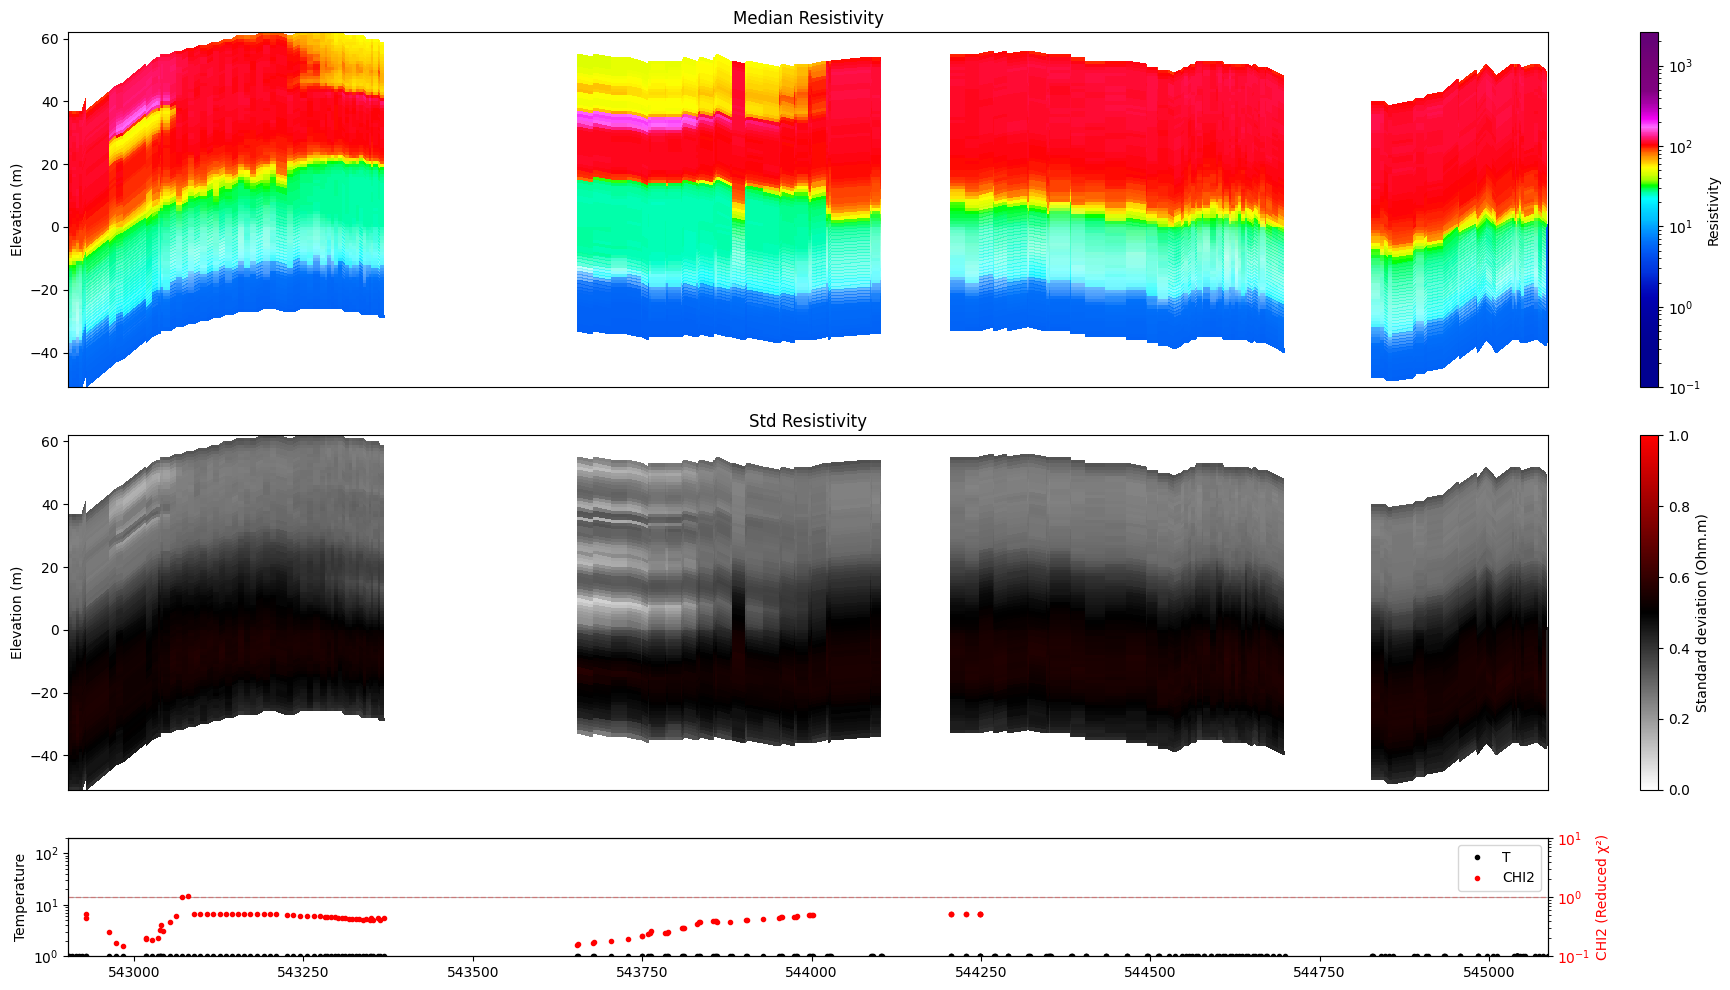

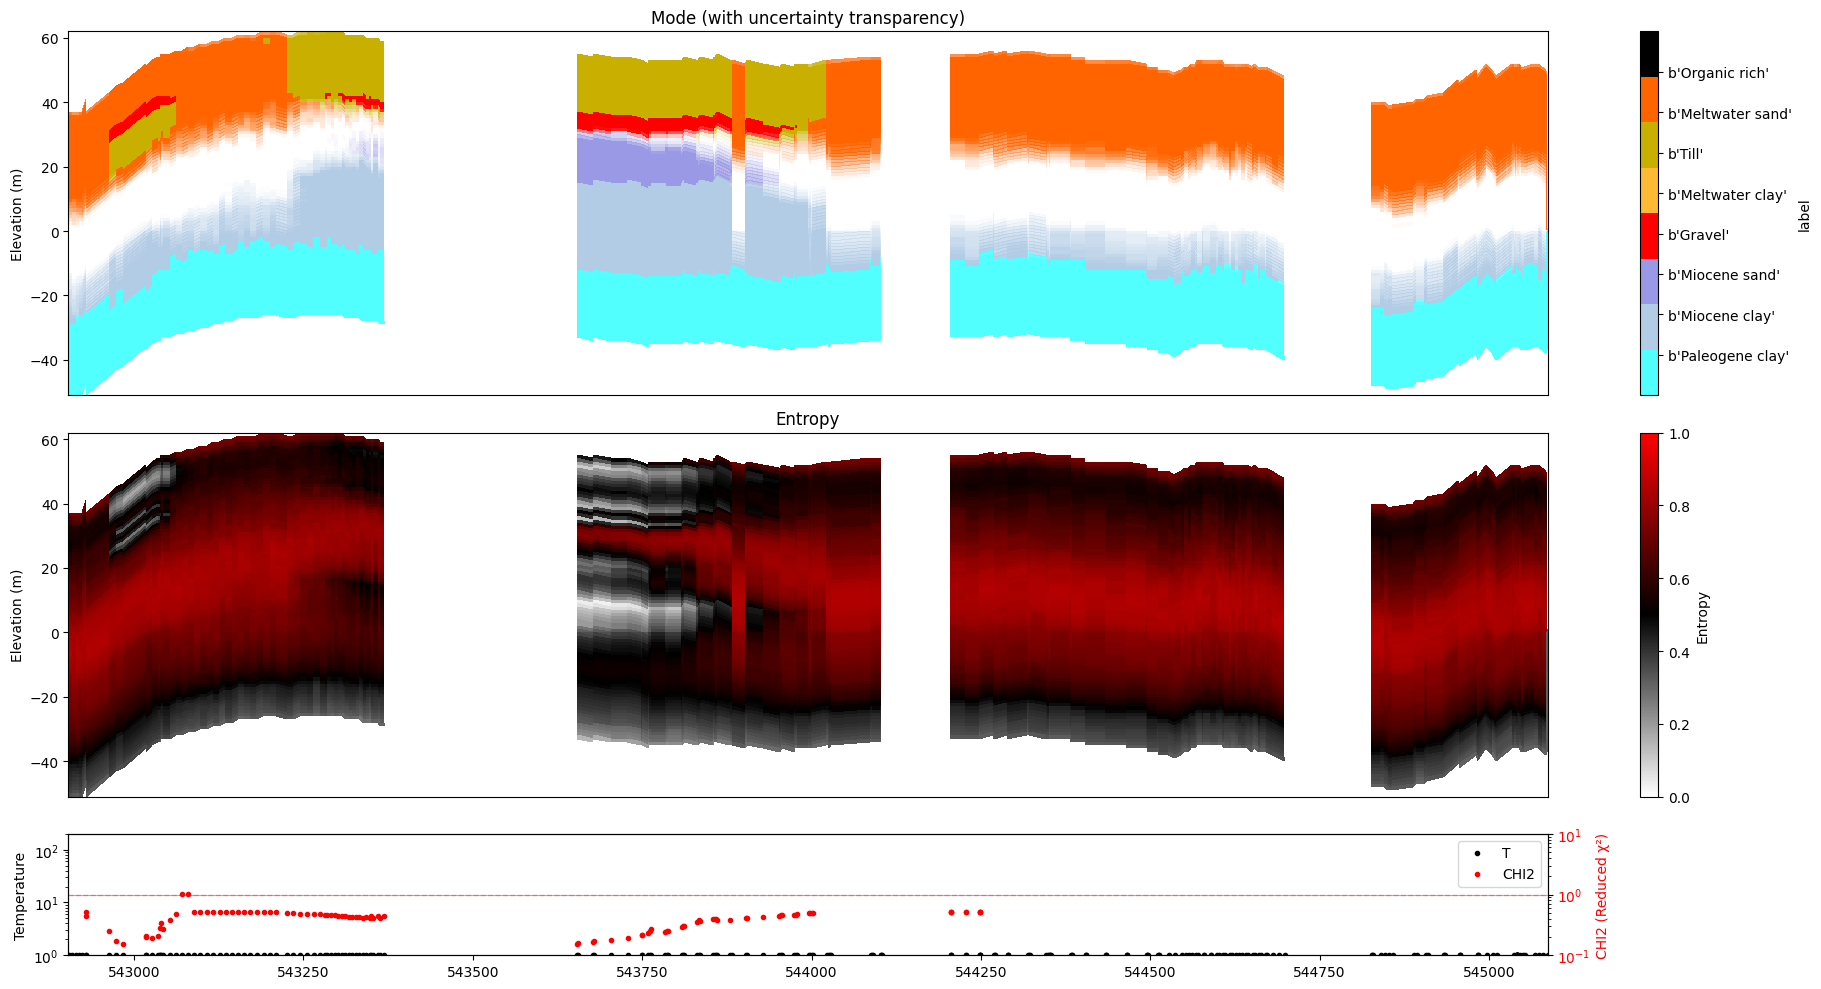

Getting cmap from attribute
0.0
1.0


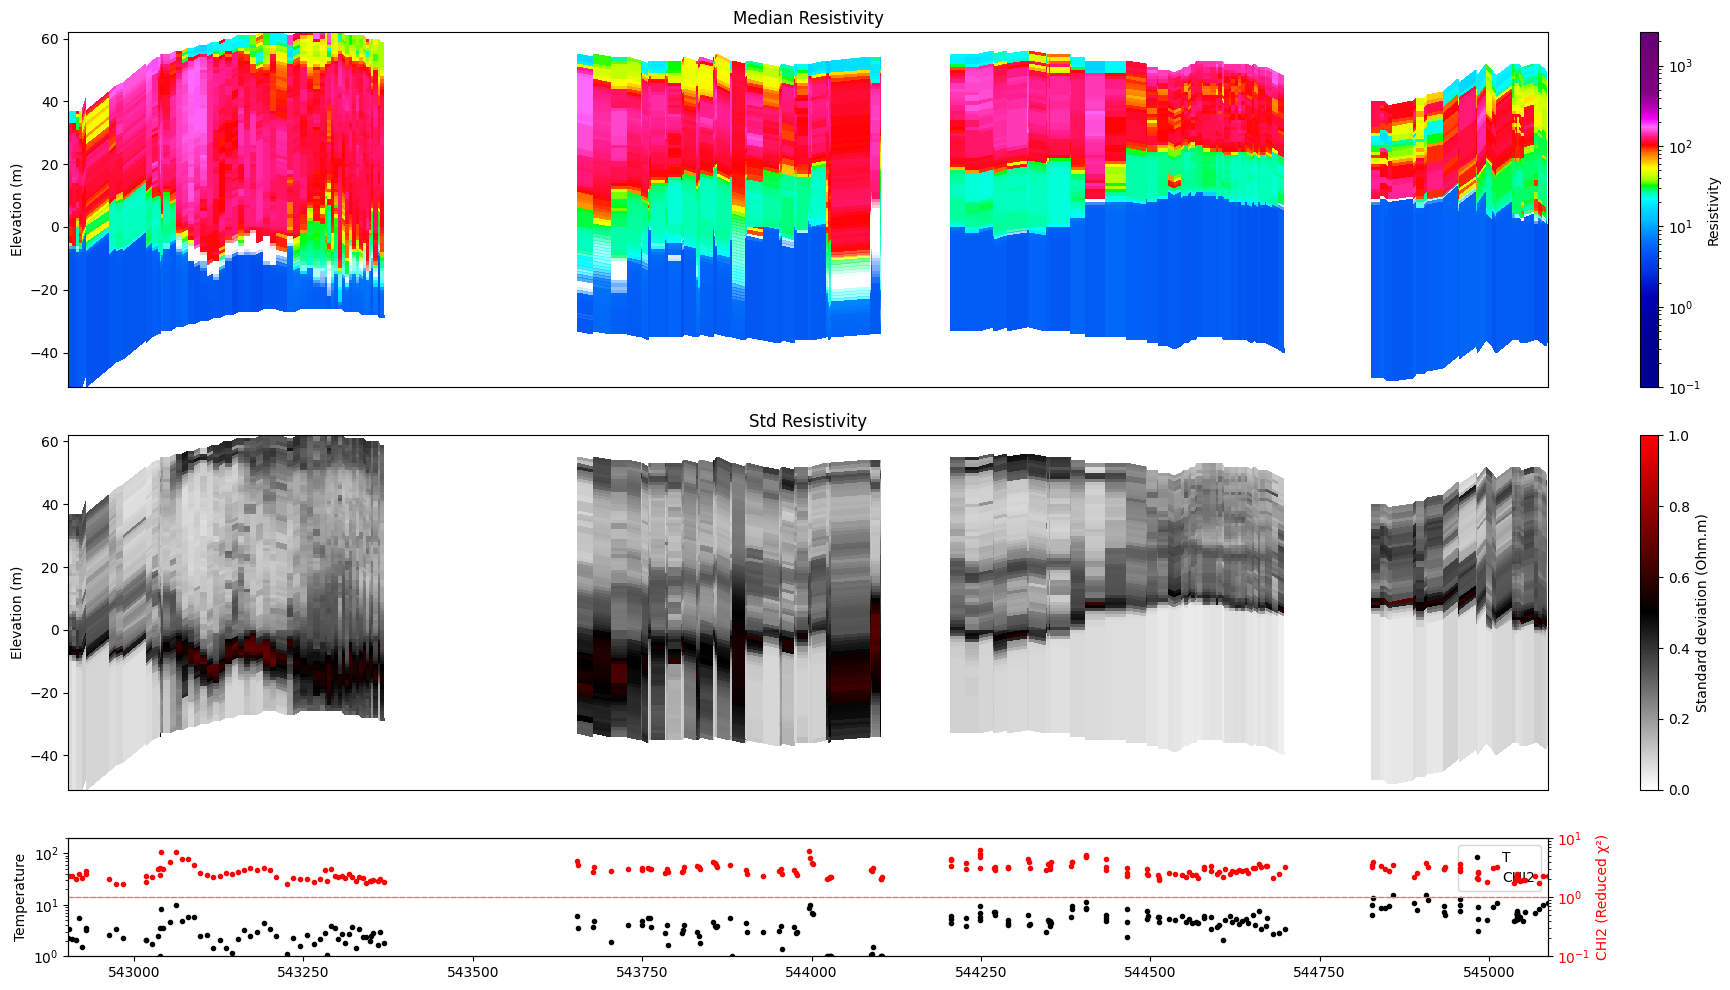

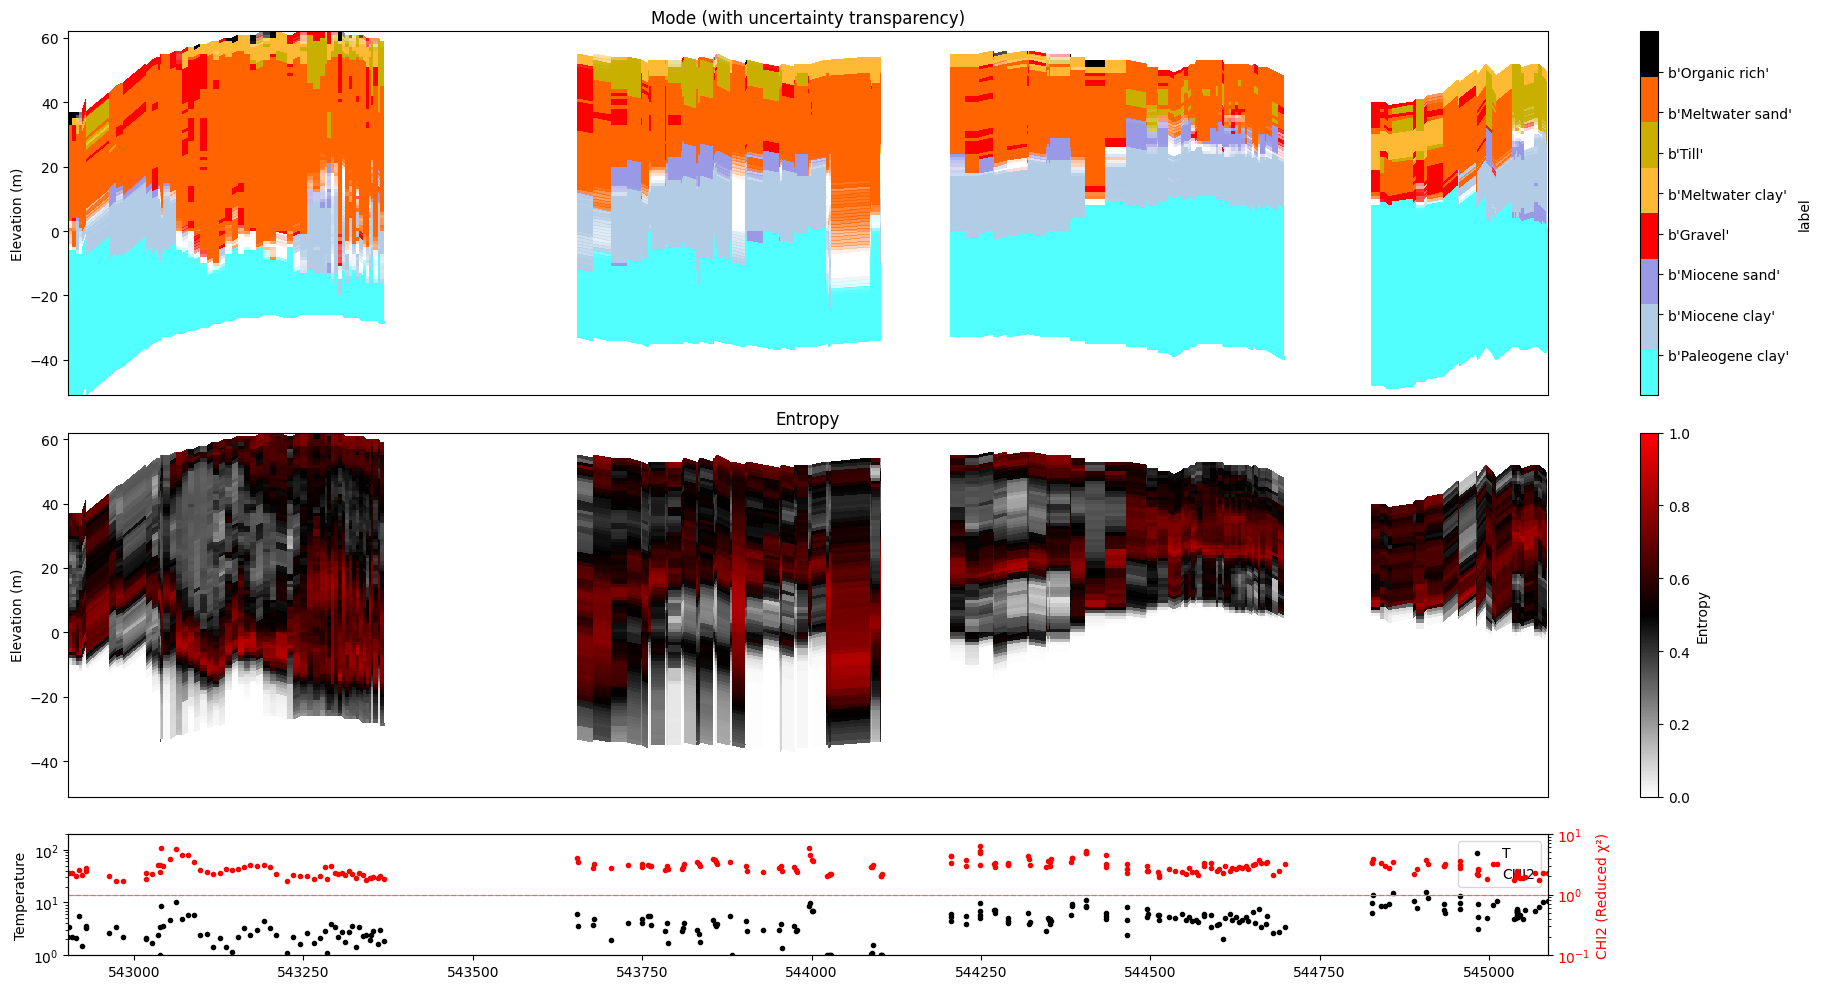

In [16]:
for f_post_h5 in f_post_h5_list:
    ig.plot_profile(f_post_h5, im=1, ii=id_line, gap_threshold=100, xaxis='x', hardcopy=hardcopy, alpha = 1,std_min = 0.5, std_max = 0.6)
    ig.plot_profile(f_post_h5, im=2, ii=id_line, gap_threshold=100, xaxis='x', hardcopy=hardcopy, alpha=1, entropy_min =0.7, entropy_max=0.8)

/M1/Median[elev=40.0m] Resistivity


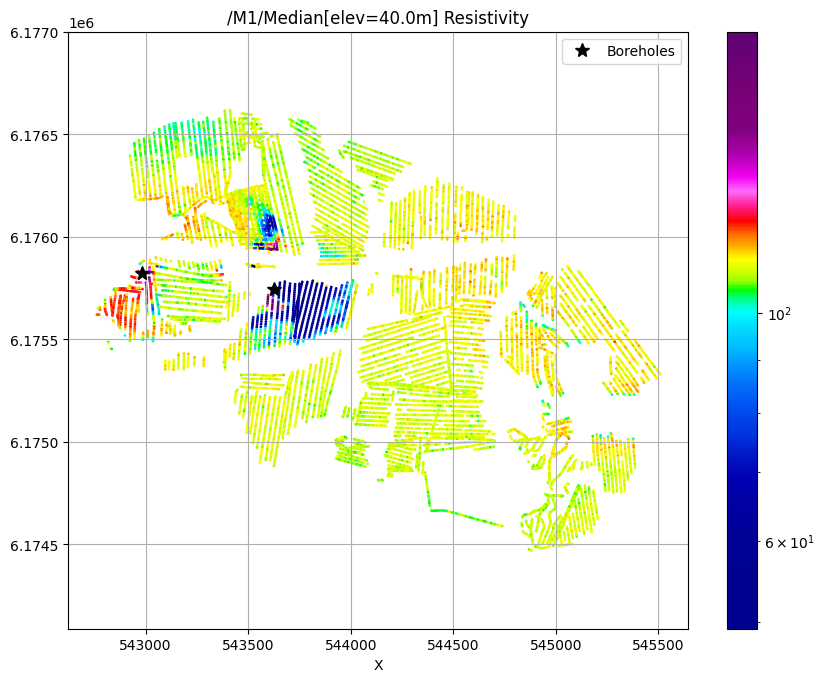

/M1/Median[elev=40.0m] Resistivity


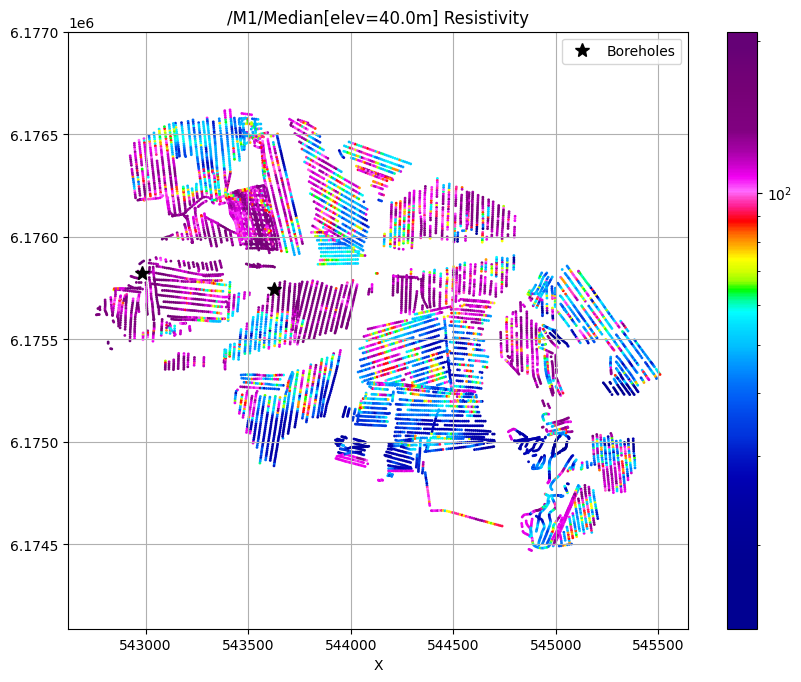

In [17]:
for f_post_h5 in f_post_h5_list:
    ig.plot_feature_2d(f_post_h5, key='Median', im=1, elevation=40)
    plt.plot(X[i_bh], Y[i_bh], 'k*', markersize=10, label='Boreholes')
    plt.legend()    
    plt.show()

/M2/Mode[elev=45.0m] Lithology


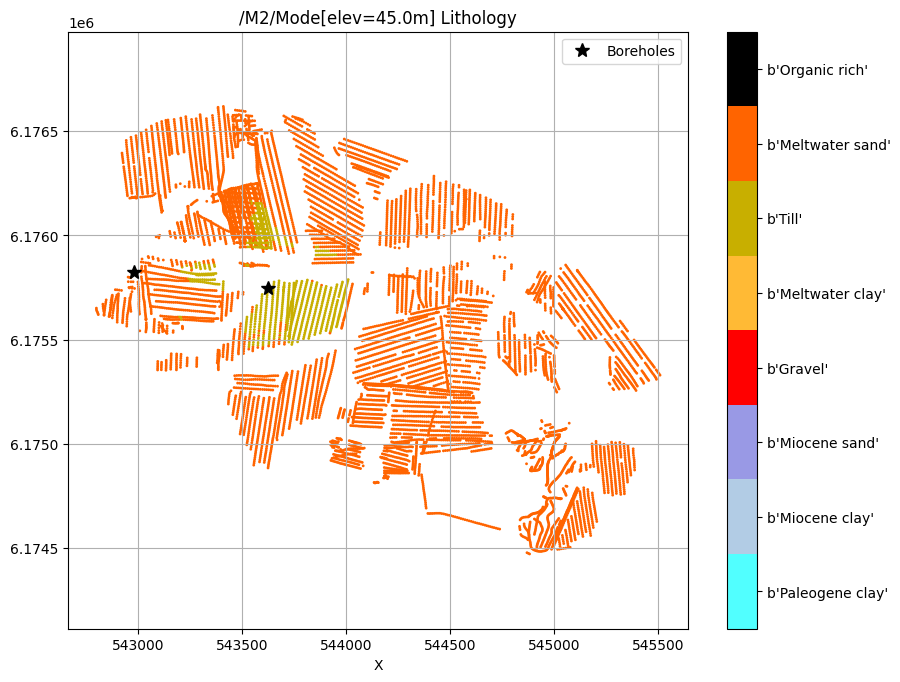

/M2/Mode[elev=45.0m] Lithology


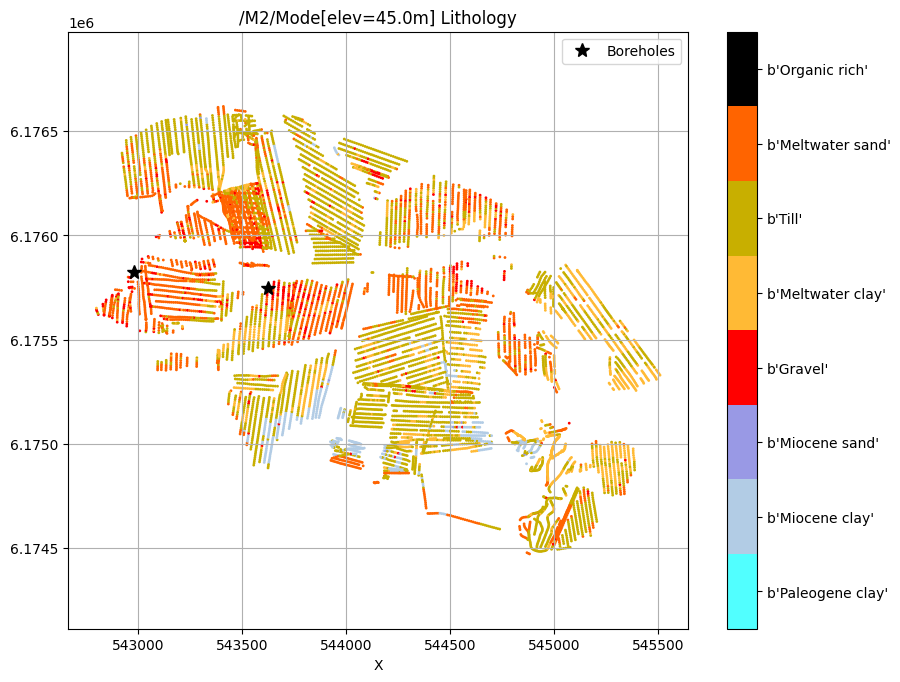

In [18]:
for f_post_h5 in f_post_h5_list:
    ig.plot_feature_2d(f_post_h5, key='Mode', im=2, elevation=45)
    plt.plot(X[i_bh], Y[i_bh], 'k*', markersize=10, label='Boreholes')
    plt.legend()    
    plt.show()

### Posterior Probability of INSIDE vs OUTSIDE
QUERY : Probability that the cumulative thickness of lithology class 2
within 0–30 m depth is greater than 10 m, and with an additional constraint: any top layer that is NOT sand/gravel
cannot be thicker than 3m.

/M3/Mode[0,:] Source File Index


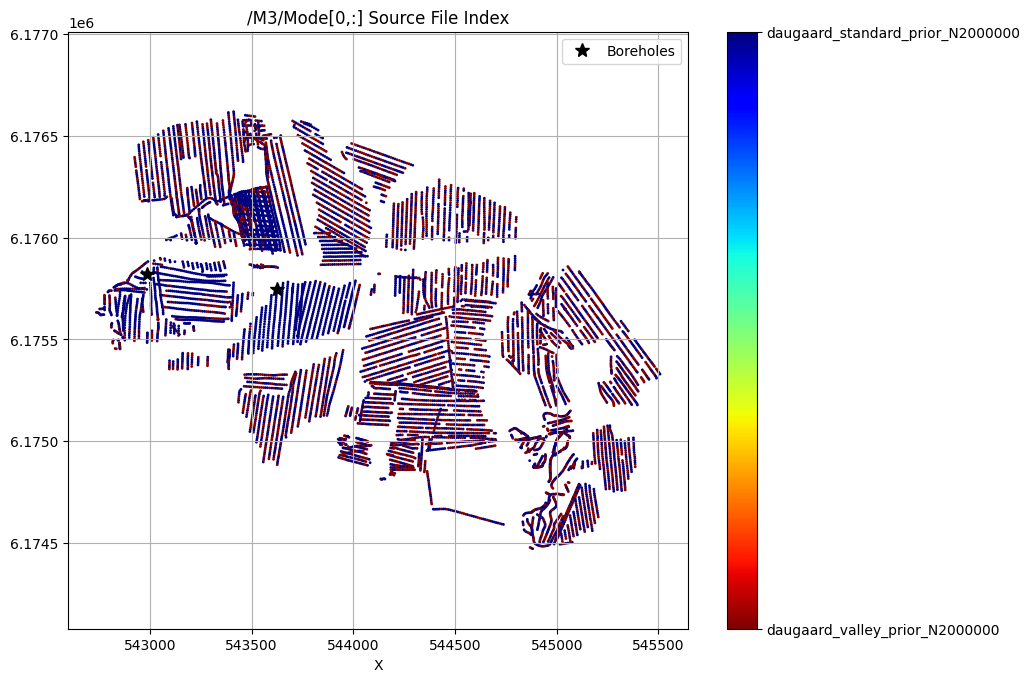

/M3/Mode[0,:] Source File Index


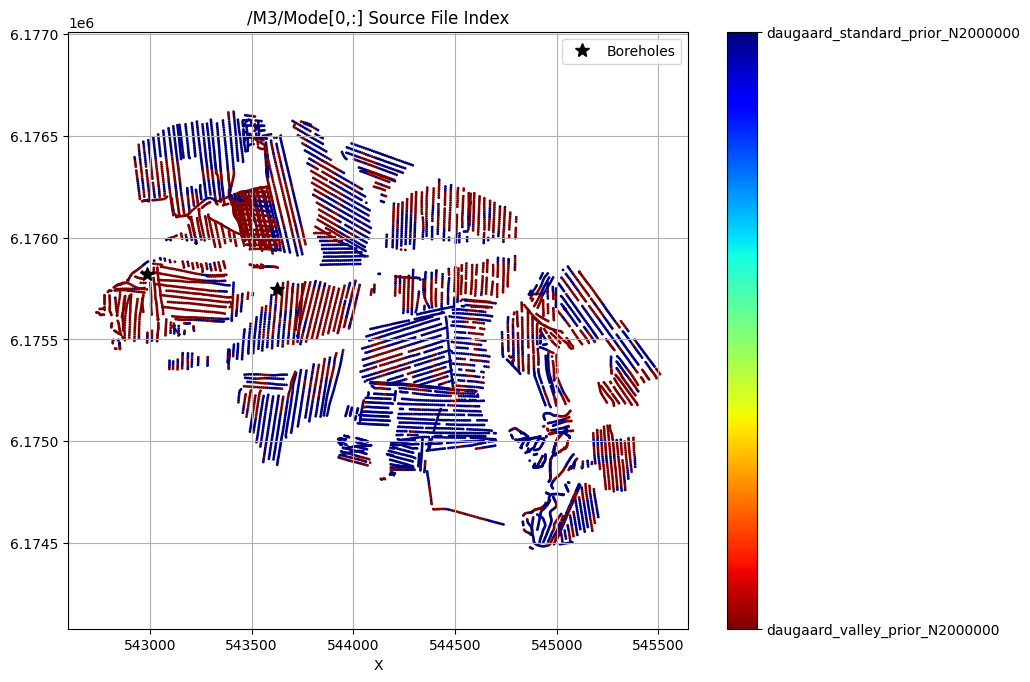

In [19]:
for f_post_h5 in f_post_h5_list:
    ig.plot_feature_2d(f_post_h5, key='Mode', im=3, iz=0, cmap='jet')
    plt.plot(X[i_bh], Y[i_bh], 'k*', markersize=10, label='Boreholes')
    plt.legend()    
    plt.show()

### QUERY POSTERIOR MODEL REALIZATIONS
QUERY : Probability that the cumulative thickness of lithology class 2
within 0–30 m depth is greater than 10 m, and with an additional constraint: any top layer that is NOT sand/gravel
cannot be thicker than 3m.

Query saved to query_daugaard.json


Evaluating query: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11693/11693 [00:27<00:00, 428.97location/s]


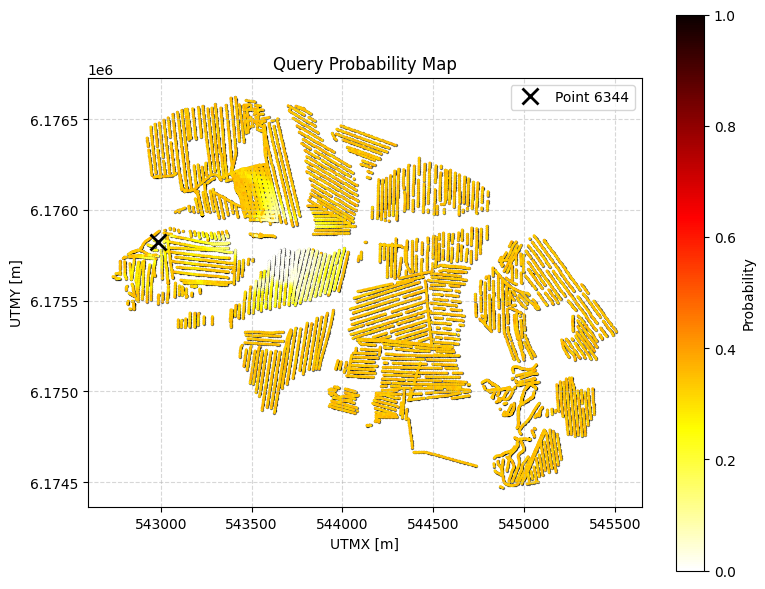

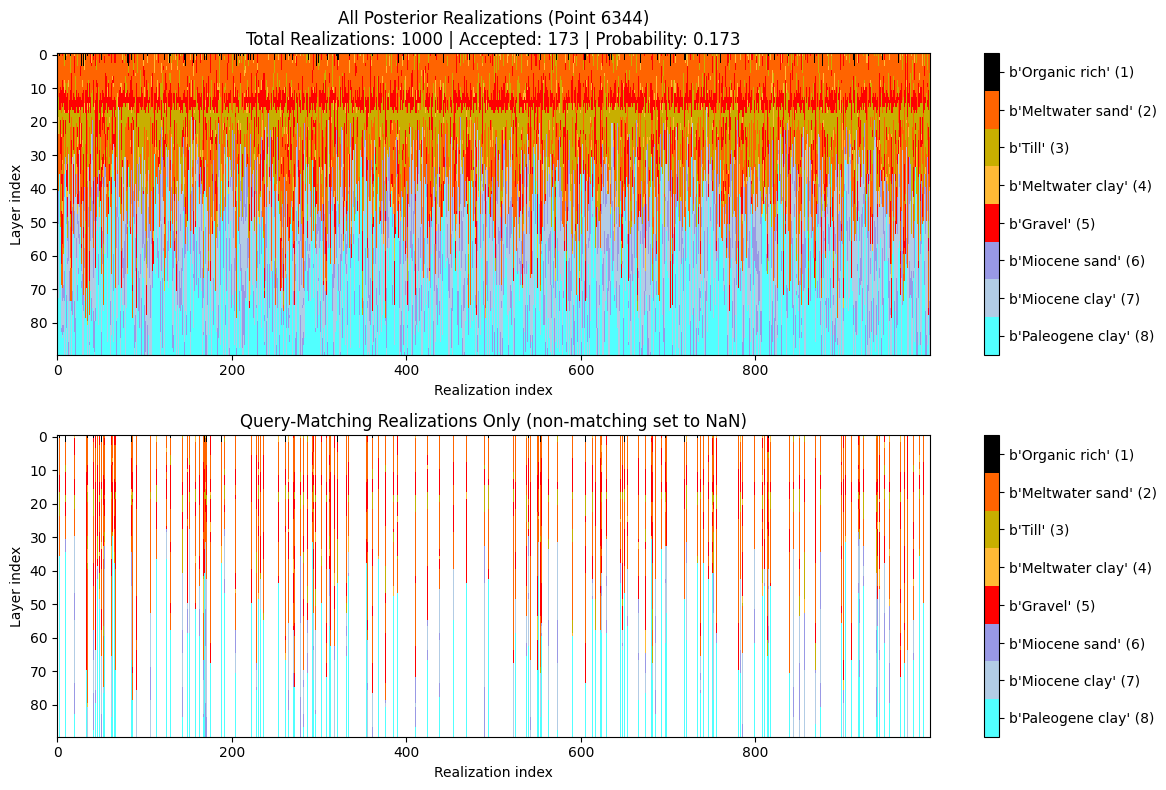

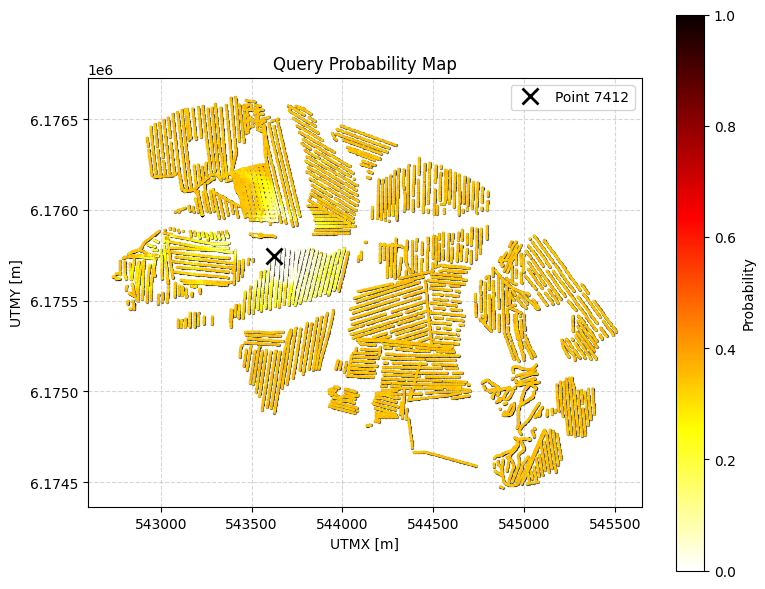

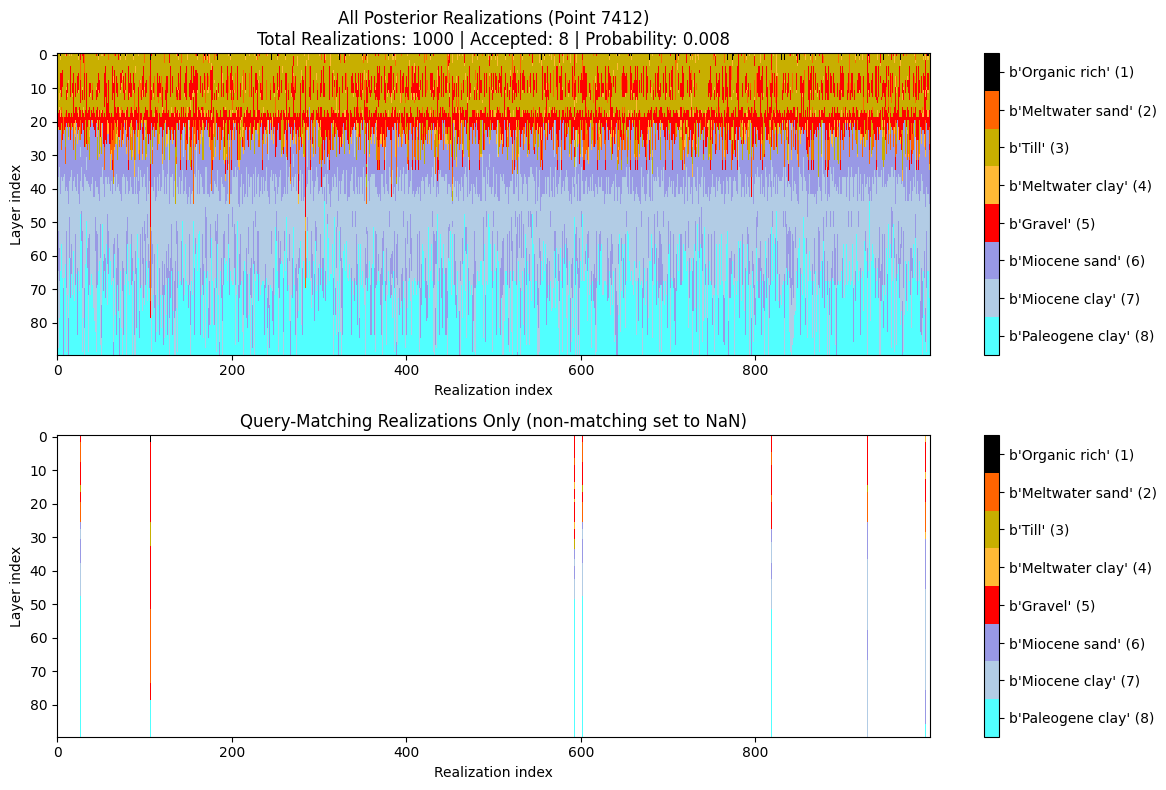

Evaluating query: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11693/11693 [00:43<00:00, 269.64location/s]


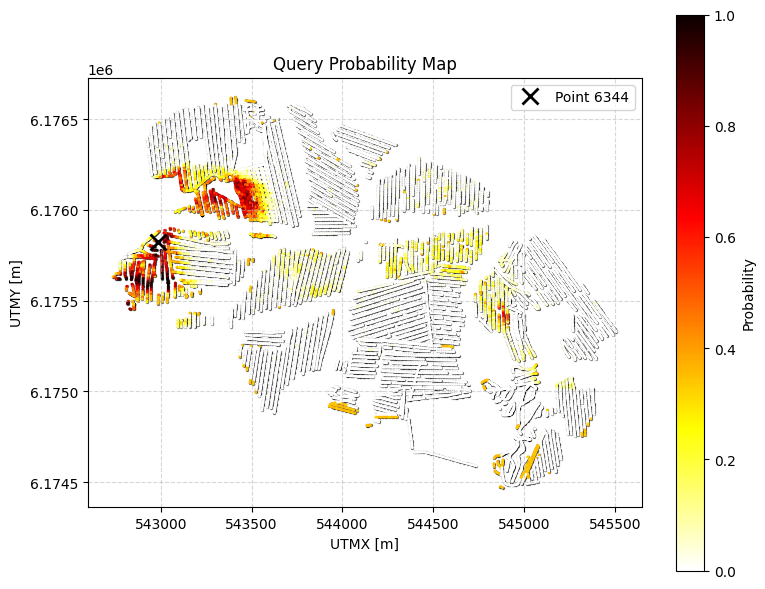

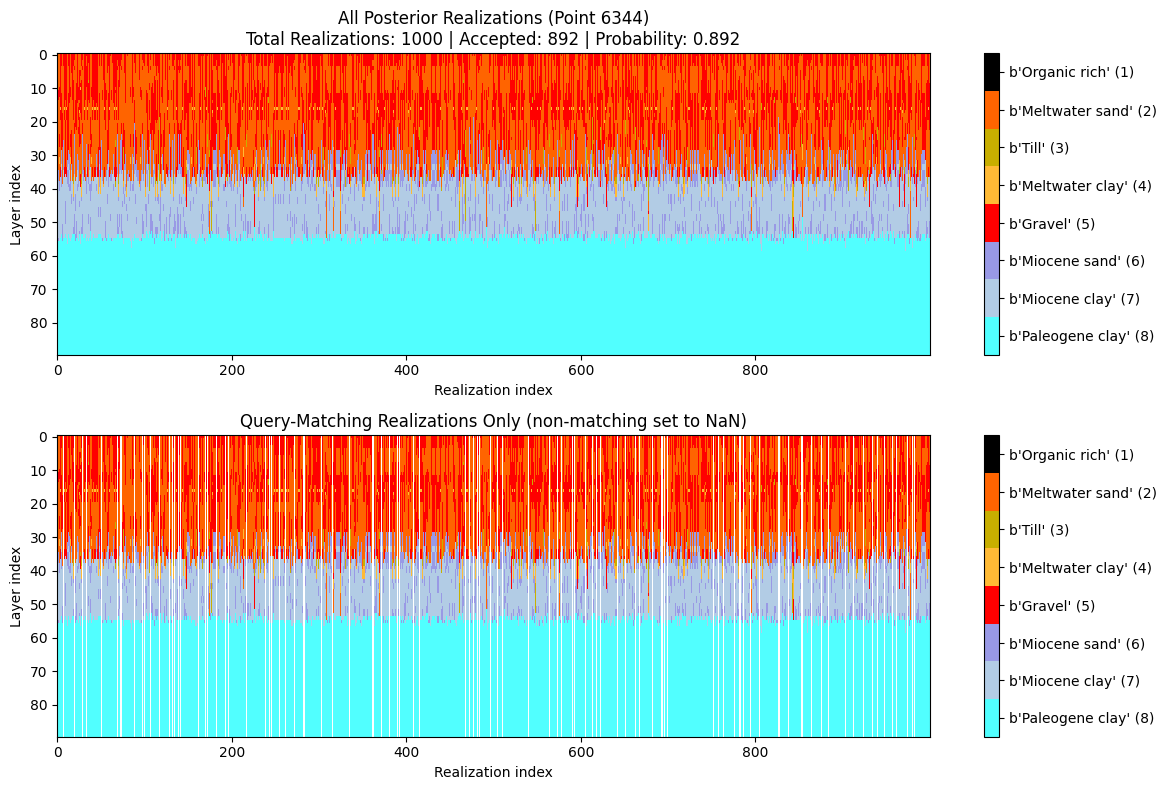

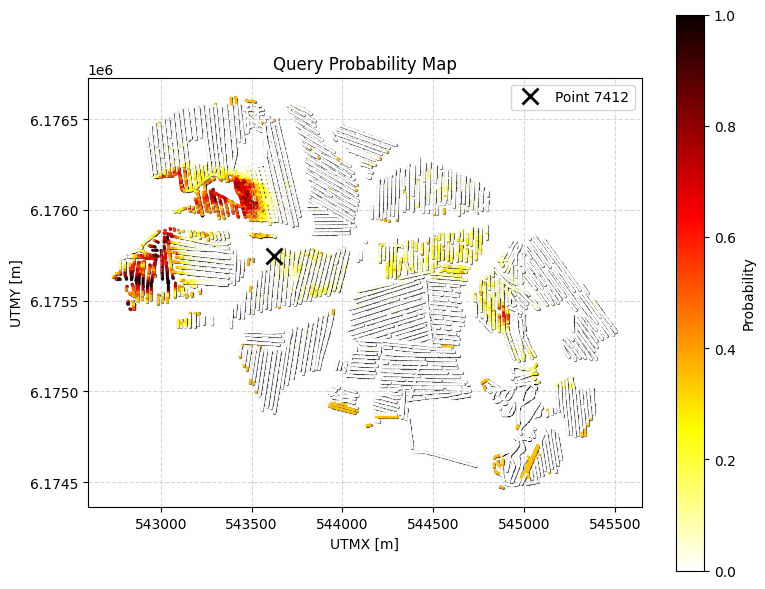

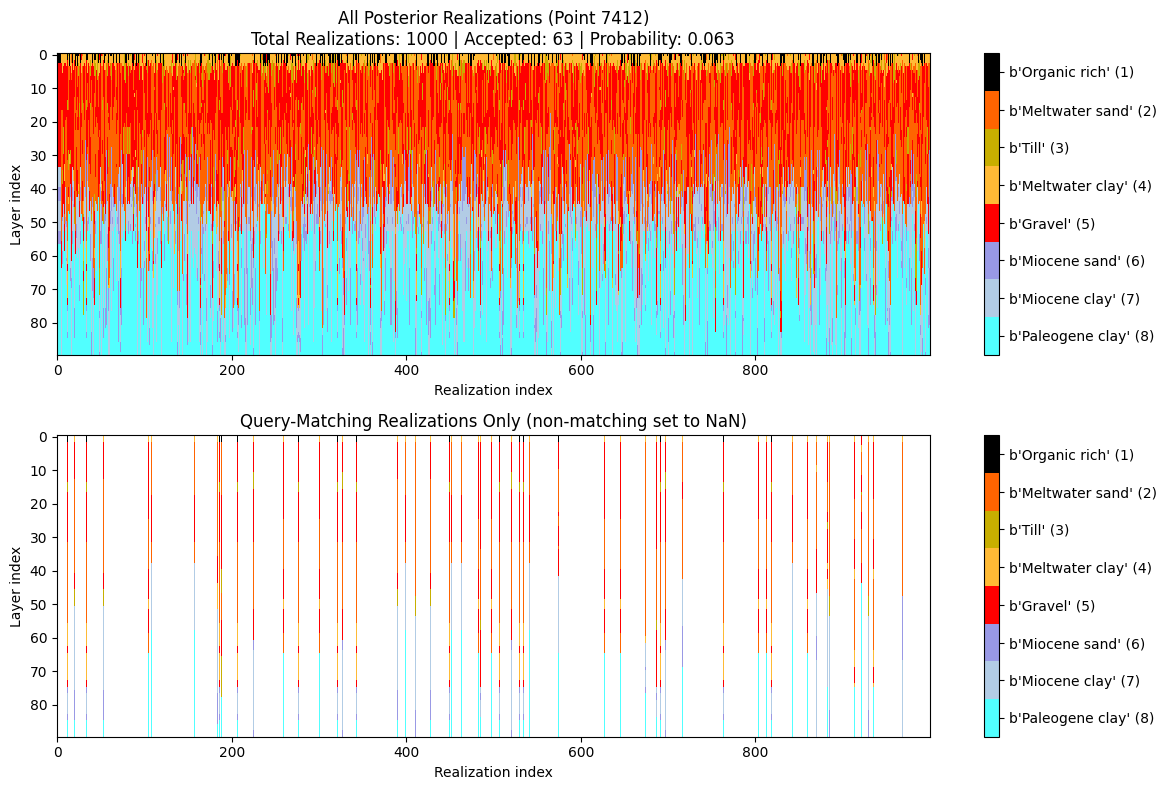

In [20]:
doLoadQuery = False
if doLoadQuery:
    query = ig.load_query('query_ex1.json')
else:
    query = {
        "constraints": [
            {
                "im": 2,
                "classes": [2, 5],
                "thickness_mode": "cumulative",
                "thickness_comparison": ">",
                "thickness_threshold": 20.0,
                "depth_min": 0.0,
                "depth_max": 30.0,
                "negate": False
            },
            {
                "im": 2,
                "classes": [1, 3, 4, 6, 7, 8],  # All classes except sand (2) and gravel (5)
                "thickness_mode": "first_occurrence",
                "thickness_comparison": "<",
                "thickness_threshold": 3.0,
                "depth_min": 0.0,
                "depth_max": 30.0,
                "negate": False
            }
        ]
    }

    ig.save_query(query, 'query_daugaard.json')

for f_post_h5 in f_post_h5_list:
    # Compute the probability of the query being satisfied for each model realization in the posterior, and get metadata about the query results (e.g. which realizations satisfy the query, etc.)
    P, meta = ig.query(f_post_h5, query)
    #  Plot the predicted probability map, and the the outcome at the borehole locations (which should be close to 1 since the query is based on the borehole data)
    ig.query_plot(P, meta, ip=i_bh[0], query_dict=query, f_post_h5=f_post_h5)
    ig.query_plot(P, meta, ip=i_bh[1], query_dict=query, f_post_h5=f_post_h5)